In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime']
dfs = [pd.read_csv(f'../traces/expiry/cf_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.01) for c in ['a', 'c', 'e', 'g']]
df = pd.concat(dfs)
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime
0,6,15,1,4,1,4,4,0,0,0,3
1,12,17,5,6,5,8,6,0,0,0,3
2,32,55,30,1,4,18,1,0,0,0,15
3,74,0,35,38,1,38,38,0,0,0,28
4,93,2501,1,91,1,91,91,3,3,0,3
...,...,...,...,...,...,...,...,...,...,...,...
368125,2764645,0,2592000,2378693,2,2491982,2378693,0,0,0,15
368126,2764675,2764675,30,2764644,1,2764644,2764644,468367,468367,0,15
368127,2764747,0,86400,2591941,1,2681434,2678342,5958,5958,0,3
368128,2764761,0,86400,2678350,1,2678350,2678350,0,0,0,24


# feature engineering

In [3]:
def calc_features(df):
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
    return df

calc_features(df)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,should_reval,generations,t_since_last,t_since_last_frac
0,6,15,1,4,1,4,4,0,0,0,3,False,1.0,2,1.000000
1,12,17,5,6,5,8,6,0,0,0,3,True,1.0,4,0.600000
2,32,55,30,1,4,18,1,0,0,0,15,True,1.0,14,0.433333
3,74,0,35,38,1,38,38,0,0,0,28,False,1.0,36,1.000000
4,93,2501,1,91,1,91,91,3,3,0,3,False,1.0,2,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368125,2764645,0,2592000,2378693,2,2491982,2378693,0,0,0,15,False,0.0,272663,0.105194
368126,2764675,2764675,30,2764644,1,2764644,2764644,468367,468367,0,15,True,1.0,31,1.000000
368127,2764747,0,86400,2591941,1,2681434,2678342,5958,5958,0,3,False,2.0,83313,0.964259
368128,2764761,0,86400,2678350,1,2678350,2678350,0,0,0,24,False,1.0,86411,1.000116


# training

In [21]:
from sklearn.model_selection import train_test_split
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import pickle

def split_xy(df):
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations', 't_since_last', 't_since_last_frac', 'mime']]
    return x, y


x, y = split_xy(df)
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(n_estimators=32, criterion = 'gini', min_samples_leaf = 200, random_state=42)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)
print(f'Train acc: {accuracy_score(y_train, rfc.predict(x_train)):0.4f}')
print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')

gini = pd.Series(rfc.feature_importances_, index=x_train.columns).sort_values(ascending=False)
display(gini)
print(classification_report(y_test, y_pred))

Train acc: 0.8924
Test acc: 0.8922


generations          0.336723
t_since_last_frac    0.313893
freq                 0.124893
t_since_last         0.087856
ttl                  0.087778
mime                 0.048857
dtype: float64

              precision    recall  f1-score   support

       False       0.91      0.96      0.93    401668
        True       0.78      0.62      0.69     96302

    accuracy                           0.89    497970
   macro avg       0.84      0.79      0.81    497970
weighted avg       0.89      0.89      0.89    497970



ROC AUC: 0.9220
Average Precision (AP): 0.7872


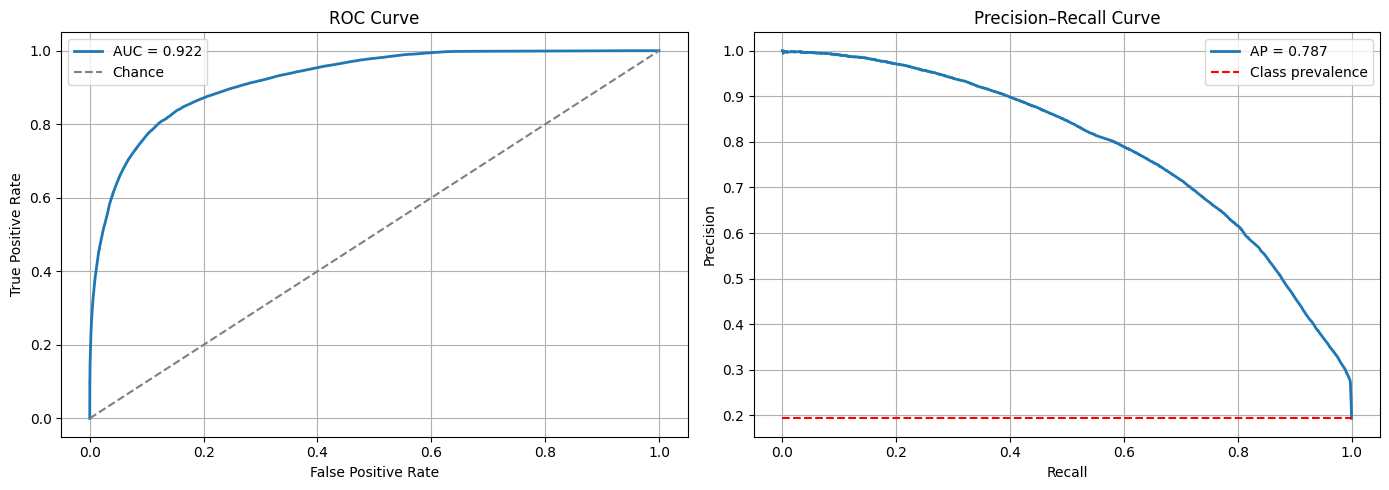

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = rfc.predict_proba(x_test)[:, 1]
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
auc_value = roc_auc_score(y_test, y_scores)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
ap_value = average_precision_score(y_test, y_scores)

plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], '--', color='gray', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_value:.3f}")
plt.hlines(y_test.mean(), 0, 1, colors='red', linestyles='--', label="Class prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

print(f"ROC AUC: {auc_value:.4f}")
print(f"Average Precision (AP): {ap_value:.4f}")

In [24]:
name = 'rfc_cf_all'
m = rfc

with open(f'../models/{name}.pkl', 'wb') as f:
    pickle.dump(m, f)

onnx = skl2onnx.to_onnx(
    m,
    initial_types=[('in', FloatTensorType([None, x_train.shape[1]]))],  # type: ignore
    options={'zipmap': False},
    verbose=1)
with open(f'../models/{name}.onnx', 'wb') as f:
    f.write(onnx.SerializeToString())  # type: ignore

[to_onnx] initial_types=[('in', FloatTensorType(shape=[None, 6]))]
[convert_sklearn] parse_sklearn_model
[convert_sklearn] convert_topology
[convert_operators] begin
[convert_operators] iteration 1 - n_vars=0 n_ops=1
[call_converter] call converter for 'SklearnRandomForestClassifier'.
[convert_operators] end iter: 1 - n_vars=3
[convert_operators] iteration 2 - n_vars=3 n_ops=1
[convert_operators] end iter: 2 - n_vars=3
[convert_operators] end.
[_update_domain_version] +opset 0: name='ai.onnx.ml', version=1
[convert_topology] +opset: name='', version=21
[convert_sklearn] end


In [7]:
import onnxruntime as ort

session = ort.InferenceSession(f'../models/{name}.onnx', providers=['CPUExecutionProvider'])
pred_ort = session.run(None, {'in': x_test[:5].to_numpy().astype(np.float32)})
pred_skl = rfc.predict_proba(x_test[:5])
print(x_test[:5])
print(f'ONNX: {pred_ort}')
print(f'SKL: {pred_skl}')

          ttl  freq  generations  t_since_last  t_since_last_frac  mime
419174   1800     1          1.0          1801           1.000000    15
31954   86400     3          1.0         23967           0.277384    15
180912      6     1          1.0             7           1.000000     6
260587   1800     1          1.0          1801           1.000000    19
19824     600     1          1.0           601           1.000000    24
ONNX: [array([0, 0, 0, 0, 0], dtype=int64), array([[0.90831786, 0.09168214],
       [0.5259483 , 0.4740517 ],
       [0.99116886, 0.00883114],
       [0.99056786, 0.00943215],
       [0.95355994, 0.04644008]], dtype=float32)]
SKL: [[0.90831787 0.09168213]
 [0.52594825 0.47405175]
 [0.99116886 0.00883114]
 [0.99056785 0.00943215]
 [0.95355992 0.04644008]]


In [8]:
x_test[:5]

,ttl,freq,generations,t_since_last,t_since_last_frac,mime
419174,1800,1,1.0,1801,1.000000,15
31954,86400,3,1.0,23967,0.277384,15
180912,6,1,1.0,7,1.000000,6
260587,1800,1,1.0,1801,1.000000,19
19824,600,1,1.0,601,1.000000,24


In [9]:
y_test[:5]

419174    False
31954     False
180912    False
260587     True
19824     False
Name: should_reval, dtype: bool

In [10]:
x_test[:1].to_numpy().astype(np.float32)

array([[1.800e+03, 1.000e+00, 1.000e+00, 1.801e+03, 1.000e+00, 1.500e+01]],
      dtype=float32)

In [11]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(16, 32, 32, 16), max_iter=200, early_stopping=True, random_state=42)
mlp.fit(x_train, y_train)

y_pred = mlp.predict(x_test)
print(f'Train acc: {accuracy_score(y_train, mlp.predict(x_train)):0.4f}')
print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
print(classification_report(y_test, y_pred))

Train acc: 0.8479
Test acc: 0.8480
              precision    recall  f1-score   support

       False       0.89      0.93      0.91    401668
        True       0.63      0.52      0.57     96302

    accuracy                           0.85    497970
   macro avg       0.76      0.72      0.74    497970
weighted avg       0.84      0.85      0.84    497970



# transferability

In [12]:
for subdf in dfs:
    subdf = calc_features(subdf)
    x, y = split_xy(subdf)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF acc: {acc:0.4f}')
    print(classification_report(y, y_pred))


CF acc: 0.8672
              precision    recall  f1-score   support

       False       0.89      0.94      0.92    243271
        True       0.77      0.62      0.69     75683

    accuracy                           0.87    318954
   macro avg       0.83      0.78      0.80    318954
weighted avg       0.86      0.87      0.86    318954

CF acc: 0.8958
              precision    recall  f1-score   support

       False       0.92      0.96      0.94    424876
        True       0.77      0.61      0.68     93656

    accuracy                           0.90    518532
   macro avg       0.84      0.78      0.81    518532
weighted avg       0.89      0.90      0.89    518532

CF acc: 0.8889
              precision    recall  f1-score   support

       False       0.91      0.96      0.93    243481
        True       0.78      0.60      0.68     59900

    accuracy                           0.89    303381
   macro avg       0.85      0.78      0.81    303381
weighted avg       0.88      

In [13]:
dffbtest = pd.read_csv(f'../traces/expiry/fb_a.csv.zst', names=cols, nrows=1000)
dffbtest = calc_features(dffbtest)
dffbtest.head()

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,should_reval,generations,t_since_last,t_since_last_frac
0,69841,0,900,68489,1,68489,68489,0,0,0,28,False,2.0,1352,1.501111
1,70517,0,900,69089,1,69089,69089,0,0,0,28,False,2.0,1428,1.585556
2,72411,0,900,71420,1,71420,71420,0,0,0,28,False,1.0,991,1.100000
3,73261,0,900,72250,1,72250,72250,0,0,0,28,False,1.0,1011,1.122222
4,74013,0,900,72990,1,72990,72990,0,0,0,28,False,1.0,1023,1.135556


In [14]:
for c in ['a', 'b', 'c']:
    dfs = pd.read_csv(f'../traces/expiry/fb_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.005)
    dfs = calc_features(dfs)
    dfs = dfs[dfs['ttl'] != 0]
    x, y = split_xy(dfs)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF {c} acc: {acc:0.4f}')
    print(classification_report(y, y_pred))

CF a acc: 0.9839
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    120608
        True       0.47      0.18      0.26      1917

    accuracy                           0.98    122525
   macro avg       0.73      0.59      0.63    122525
weighted avg       0.98      0.98      0.98    122525

CF b acc: 0.9871
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    356504
        True       0.40      0.16      0.23      4332

    accuracy                           0.99    360836
   macro avg       0.70      0.58      0.61    360836
weighted avg       0.98      0.99      0.98    360836

CF c acc: 0.9924
              precision    recall  f1-score   support

       False       0.99      1.00      1.00    296126
        True       0.49      0.30      0.38      2238

    accuracy                           0.99    298364
   macro avg       0.74      0.65      0.69    298364
weighted avg       0.99

In [15]:
dfwm = pd.read_csv(f'../traces/expiry/wm_t.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.002)
dfwm = calc_features(dfwm)
dfwm = dfwm[dfwm['ttl'] != 0]
x, y = split_xy(dfwm)
y_pred = rfc.predict(x)
acc = accuracy_score(y, y_pred)
print(f'CF {c} acc: {acc:0.4f}')
print(classification_report(y, y_pred))

CF c acc: 0.7943
              precision    recall  f1-score   support

       False       0.78      0.91      0.84     56979
        True       0.83      0.62      0.71     38811

    accuracy                           0.79     95790
   macro avg       0.80      0.77      0.78     95790
weighted avg       0.80      0.79      0.79     95790



In [16]:
dffba = pd.read_csv(f'../traces/expiry/fb_a.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.005)
dffba = calc_features(dffba)
dffba.head()

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,should_reval,generations,t_since_last,t_since_last_frac
0,69841,0,900,68489,1,68489,68489,0,0,0,28,False,2.0,1352,1.501111
1,186022,0,900,185077,2,185080,185077,53,51,0,28,False,1.0,942,1.045556
2,186778,5103255,900,185873,1,185873,185873,53,51,0,28,False,1.0,905,1.004444
3,212560,0,900,211648,1,211648,211648,56,53,0,28,False,1.0,912,1.012222
4,214343,0,900,213432,2,213486,213432,56,53,0,28,False,1.0,857,0.951111
